# **HELLO, Curious Mind!** 👋
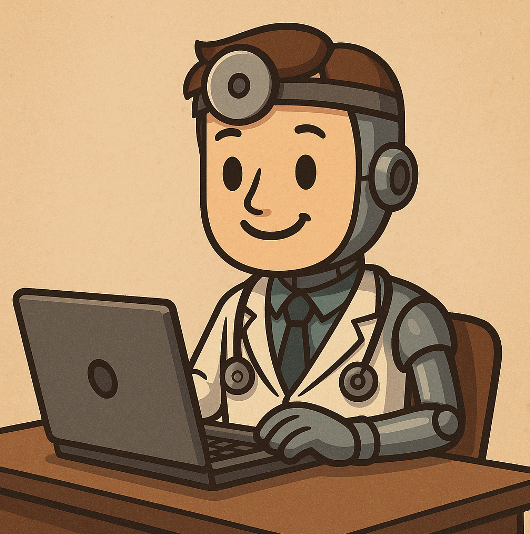


Welcome to this interactive notebook, where you'll explore 3 unique clinical cases, each posing exciting challenges for you to solve!

For every case, you'll find three levels of questions:

**🎯 Beginner** - No programming needed! Just explore and interact with available LLMs.  
**🧩 Intermediate** - Requires a bit more insight and critical thinking about the topic.  
**🧠 Advanced** - Time for our brilliant computer science minds to step in and help tackle more complex issues.  

Each task includes guidelines and some extra resources to support you along the way.
We’re nearby, just raise your hand if you have any questions or want to discuss your ideas.

***Let’s explore, learn, and have fun together!***

---




# **Environment Setup**

## 🔐 Best Practices: API Keys & Environment Management

### 1️⃣  Never store API keys in your notebook
Notebooks (`.ipynb`) are shared, committed to git, and accidentally published. Hardcoded keys in cells are a security risk.

**For this Colab session** we use `getpass()` — your key is entered interactively and never stored in the notebook.

**For local development** store keys in a `.env` file and load them with `python-dotenv`:
```
# .env  ← add to .gitignore, never commit!
OPENAI_API_KEY=sk-your-key-here
```
```python
from dotenv import load_dotenv
import os
load_dotenv()                              # reads .env automatically
client = OpenAI(api_key=os.environ["OPENAI_API_KEY"])
```

### 2️⃣  Use `uv` instead of `pip`
[`uv`](https://github.com/astral-sh/uv) is a modern Python package manager: **10–100× faster** than pip with correct dependency resolution.

```bash
# ── Local project setup ───────────────────────────────────────
uv init my-llm-project && cd my-llm-project
uv add openai PyMuPDF faiss-cpu gradio

# ── In Google Colab (one-liner) ───────────────────────────────
pip install uv -q && uv pip install openai PyMuPDF faiss-cpu gradio --system -q
```

In [1]:
# Install required packages and modules for this notebook.

!pip install --quiet openai PyMuPDF tiktoken faiss-cpu ddgs openai-agents

In [ ]:
# Import libraries
import os
from getpass import getpass
import fitz
from openai import OpenAI, AsyncOpenAI
import faiss
import numpy as np
from getpass import getpass
#from google.colab import files
from typing import List
import textwrap
from pathlib import Path
import fitz
from IPython.display import display, Markdown


In [3]:
# ── Uncomment for local development (.env approach) ───────────
from dotenv import load_dotenv
load_dotenv()

#via external network
#client = OpenAI(base_url="https://api.kather.ai", api_key=os.environ["Katherlab_Local"])

#katherlab local network
client = OpenAI(base_url="http://pluto/v1/", api_key=os.environ["Katherlab_Local"])

# ── Uncomment to use uv in Colab (faster than plain pip) ──────
# !pip install uv -q
# !uv pip install openai PyMuPDF tiktoken faiss-cpu ddgs openai-agents gradio openpyxl --system -q

print("💡 Remember: .env files for secrets, uv for package management.")

💡 Remember: .env files for secrets, uv for package management.


# **OpenAI LLM Client Initialization**

In [4]:
# Please enter the OPENAI_API_KEY that we shared with you.

# os.environ["OPENAI_API_KEY"] = getpass("Enter your OpenAI API key: ")
# client = OpenAI(api_key=os.environ["OPENAI_API_KEY"])

os.environ["OPENAI_API_KEY"] = getpass("Enter your API key: ")
client = OpenAI(base_url="https://api.kather.ai", api_key=os.environ["OPENAI_API_KEY"])
#agen"])

In [5]:
# List all models available to your account
models = client.models.list()

# Print the IDs of all available models
print("✅ Models available to your API key:")
for model in models.data:
    print("-", model.id)

✅ Models available to your API key:
- GPT-OSS-120B
- Qwen3-Embedding-8B
- gemma-4-31B-it


--------

# **🤒 Case 1 – Metabolic dysfunction‑associated steatotic liver disease (MASLD)**


**Vignette:**

`Ms K., 48, teaches at a rural primary school in Saxony. She attends a preventive health check. She drinks no alcohol, exercises once a week and takes no regular medication.`

**Family history:**

`type 2 diabetes. Weight 86 kg, height 1.63 m (BMI 32).`

**Physical exam:**

`Blood pressure 138/84 mmHg, pulse 74/min, waist 102 cm, no stigmata of chronic liver disease, mild axillary acanthosis nigricans.`

**Ultrasound:**

`Homogeneous hyperechogenic liver, regular contour, spleen 11 cm, no ascites.`

**Laboratory (fasting):**

`ALT 58 U/l, AST 45 U/l, GGT 62 U/l, ALP 88 U/l, bilirubin 0.6 mg/dl, platelets 245 × 10⁹/l, HbA1c 6.0 %, triglycerides 220 mg/dl, HDL 38 mg/dl; Fib‑4 1.6`

---

## 🎯 **Easy Task (LLMs)**:  What is the the working diagnosis for this patient?


### ⁉️ **Todo:** Please rephrase the question you would like to ask the model.

In [6]:
question = "Your Question?"

#### ✅ **Answer:**

In [7]:
question = """
What is the working diagnosis for this patient?

Vignette:
Ms K., 48 years old, teaches at a rural primary school in Saxony. She attends a preventive health check. She drinks no alcohol, exercises once a week, and takes no regular medication.

Family history:
Type 2 diabetes.

Anthropometry:
Weight: 86 kg, height: 1.63 m (BMI 32).

Physical examination:
Blood pressure: 138/84 mmHg, pulse: 74/min, waist circumference: 102 cm, no stigmata of chronic liver disease, mild axillary acanthosis nigricans.

Ultrasound:
Homogeneous hyperechogenic liver, regular contour, spleen size: 11 cm, no ascites.

Laboratory (fasting):
ALT: 58 U/l, AST: 45 U/l, GGT: 62 U/l, ALP: 88 U/l, bilirubin: 0.6 mg/dl, platelets: 245 × 10⁹/l, HbA1c: 6.0 %, triglycerides: 220 mg/dl, HDL: 38 mg/dl; Fib‑4: 1.6.
"""

#### 👩‍💻 👨‍💻 **Test:**

In [8]:
response = client.chat.completions.create(
    model="GPT-OSS-120B",
    messages=[
        {"role": "system", "content": "You are a helpful medical assistant."},
        {"role": "user", "content": question}
    ]
)

In [12]:
answer = response.choices[0].message.content
print("\n📌 Answer:\n")

Markdown(answer)


📌 Answer:



**Working diagnosis (most likely): Non‑alcoholic fatty liver disease (NAFLD) – early‑stage steatosis, probably non‑alcoholic steatohepatitis (NASH) without significant fibrosis.**  

---

### Why this fits the picture

| Finding | How it supports NAFLD/NASH |
|---------|----------------------------|
| **Age & sex** – 48‑year‑old woman | NAFLD is common in middle‑aged adults, especially women after the fourth decade. |
| **Obesity** – BMI 32 kg/m², waist 102 cm | Central obesity is a core component of the metabolic syndrome and the strongest risk factor for hepatic steatosis. |
| **Metabolic abnormalities** – ↑triglycerides (220 mg/dL), low HDL (38 mg/dL), borderline‑elevated HbA1c (6.0 %) and a family history of type 2 diabetes | These constitute the dyslipidemia and impaired glucose tolerance that accompany NAFLD. |
| **Acanthosis nigricans** (axillary) | Cutaneous marker of insulin resistance, often present in NAFLD. |
| **Liver enzymes** – ALT 58 U/L, AST 45 U/L, GGT 62 U/L (mild‑to‑moderate elevation) | Typical “hepatic injury” pattern in NAFLD; ALT>AST is common. |
| **Abdominal US** – Homogeneous hyperechogenic liver, normal contour, no ascites or focal lesion | Classic sonographic appearance of hepatic steatosis (fatty infiltration). |
| **Fib‑4 score** = 1.6 (age 48, AST 45, ALT 58, platelets 245) | A Fib‑4 < 1.3 virtually excludes advanced fibrosis; 1.3‑2.67 is an “indeterminate” zone. 1.6 suggests low‑to‑moderate risk of fibrosis, consistent with early disease. |
| **No alcohol use, no hepatotoxic drugs, no chronic viral hepatitis history** | Excludes other common causes of liver injury, leaving NAFLD as the leading diagnosis. |

---

### How to phrase the *working* diagnosis

> **Working diagnosis:** “Metabolic‑associated fatty liver disease (MAFLD) – likely non‑alcoholic fatty liver disease with early steatohepatitis, low probability of significant fibrosis (Fib‑4 ≈ 1.6).”

*(Note: “MAFLD” is the preferred contemporary term that emphasizes the underlying metabolic drivers.)*

---

## Next steps – What to do to confirm/stage the disease

1. **Exclude other causes** (if not already done):
   * Hepatitis B & C serology (or PCR if indicated).
   * Iron studies (ferritin, transferrin saturation) to rule out hemochromatosis.
   * Autoimmune markers (ANA, ASMA) only if clinical suspicion.

2. **Risk stratification for fibrosis**  
   * Repeat Fib‑4 after 6–12 months (trend matters).  
   * Consider **enhanced liver fibrosis (ELF) test** or **transient elastography (FibroScan)** – a liver stiffness < 8 kPa would corroborate low‑grade fibrosis; > 8‑10 kPa would prompt closer evaluation.

3. **Lifestyle‑focused management** (the cornerstone of therapy):
   * **Weight loss:** Aim for ≥ 7‑10 % total body weight reduction (≈ 6–8 kg) – this improves steatosis and can reverse early NASH.
   * **Diet:** Mediterranean‑style diet (high in monounsaturated fats, nuts, fish, vegetables, low in refined carbs/sugars). Limit fructose‑rich beverages.
   * **Physical activity:** At least 150 min/week of moderate‑intensity aerobic exercise (e.g., brisk walking) plus resistance training 2‑3 times per week.
   * **Control of dyslipidemia & pre‑diabetes:** Consider statin therapy (safe in NAFLD) to lower triglycerides & raise HDL; assess need for metformin if fasting glucose/OGTT crosses diabetic threshold.

4. **Monitoring schedule**
   * **Labs** (ALT, AST, lipid panel, HbA1c) every 6 months.
   * **Ultrasound** annually (or sooner if enzymes rise).
   * **Fibrosis assessment** (FibroScan or repeat Fib‑4) annually or sooner if clinical change.

5. **Pharmacologic options** (currently reserved for higher‑risk or progressive disease):
   * **Pioglitazone** (off‑label) can improve NASH in non‑diabetic patients but has weight‑gain side‑effects.
   * **GLP‑1 receptor agonists** (e.g., liraglutide, semaglutide) – shown to reduce steatosis & inflammation; may be considered if she develops overt type 2 diabetes or needs additional weight loss.
   * **Vitamin E** (800 IU/day) – may be used in non‑diabetic NASH but contraindicated in patients with a history of hemorrhagic stroke or those taking anticoagulants.

6. **Vaccinations** (important in chronic liver disease):
   * Hepatitis A and B (if non‑immune).
   * Annual influenza, COVID‑19 boosters, pneumococcal as per age/comorbidity.

---

## Take‑home summary for the clinician

| Item | Action |
|------|--------|
| **Diagnosis** | Metabolic‑associated fatty liver disease (MASLD/NAFLD) with probable early NASH; low‑to‑moderate fibrosis risk (Fib‑4 ≈ 1.6). |
| **Key risk factors** | Obesity (BMI 32), central adiposity, dyslipidemia, insulin resistance (acanthosis nigricans, HbA1c 6%). |
| **Immediate priority** | Initiate structured lifestyle programme (diet, exercise, weight‑loss goal ≥ 7 %). |
| **Diagnostic confirmation** | Order serologies to rule out viral hepatitis + consider transient elastography for fibrosis staging. |
| **Follow‑up** | Labs & weight check q6 months; imaging/fibrosis assessment annually. |
| **Patient education** | Emphasize that NAFLD is reversible with weight loss; discuss realistic goals; reassure that current fibrosis risk appears low but requires monitoring. |

---

**Bottom line:** The clinical picture is classic for metabolic‑associated fatty liver disease (formerly NAFLD) with early steatohepatitis. With targeted lifestyle modification and periodic fibrosis monitoring, most patients in this stage can achieve histologic improvement and avoid progression to advanced fibrosis or cirrhosis.

#### 🤷‍♀️ 🤷‍♂️ **Discuss:** Is the provided answer correct?!
---

### ⁉️ **Todo:** Please check following link ([API Parameters](https://chrisyandata.medium.com/a-comprehensive-guide-to-openai-gpt-model-api-parameters-c2c6dff9ce19)) and discuss different API parameters within your group.

#### Evaluate different parameters and discuss their effect. Here are some ideas:

**1️⃣ How does the model's behavior change when increasing the temperature parameter from 0 to higher values?**

→ (Explore how randomness and creativity are affected.)

**2️⃣ What is the impact of adjusting the presence_penalty on the diversity of the model’s responses?**

→ (Observe whether the model introduces new topics or sticks to known ones.)

**3️⃣ Does reducing the max_tokens parameter affect the completeness or accuracy of the response?**

  → *(Check whether shorter responses result in omitted or less accurate information.)*

**4️⃣ Which parameters are most influential in improving the factual correctness or reliability of the model’s answers?**

→ (Consider temperature, system prompts, and message structure.)

**5️⃣ How does the system prompt influence the tone and structure of the response?**

  → *Try comparing prompts like "You are a strict scientific assistant" vs. "You are a creative storyteller."*

**6️⃣ Does the model provide consistent answers to the same question with different temperatures or contexts?**

→ Investigate the model’s variability and reproducibility.

**7️⃣ What happens when you use stop sequences to control where the model halts its response?**

**8️⃣ How does the model handle ambiguous or poorly phrased questions?**

→ Try testing how robust it is to input quality.

**9️⃣ What is the trade-off between temperature and top_p when both are adjusted?**

## 🧩 **Medium Task (Retrieval-Augmented Generation)**:  Check the 2024 EASL MASLD guideline: decide whether further fibrosis work‑up* is needed.

#### **work up means a continuous follow-up (usually by ultrasound + elastrography of the liver) to monitor potential worsening of fibrosis*

### **Guideline:** [EASL 2024 MASLD MetALD](https://drive.google.com/file/d/1d1TQgDV3lbEEjPxD5D-x6fSO3t_9KPxl/view?usp=sharing)


---

### 🤷‍♀️ 🤷‍♂️ **Discuss:** How much time would it take you, without any AI assistance, to carefully read the provided guideline PDF and manually find the correct answer to the patient vignette question??!
---

### 👩‍💻 👨‍💻 **Test:** Query Zero-Shot LLM regarding guideline

In [ ]:
response = client.chat.completions.create(
    model="GPT-OSS-120B",
    messages=[
        {"role": "system", "content": "You are a helpful medical assistant."},
        {"role": "user", "content": "Give me the details of 2024 EASL MASLD guideline"}
    ]
)

In [ ]:
answer = response.choices[0].message.content
print("\n📌 Answer:\n")
print(textwrap.fill(answer, width=100))

#### 🤷‍♀️ 🤷‍♂️ **Discuss:** Why this is happening??! What is your solution??
---

## **ℹ️ Retrieval-augmented generation (RAG)**

Zero-shot LLMs are remarkable at producing fluent text on virtually any topic, but their answers come solely from the patterns learned during training. Although large language models show great promise for high-stakes tasks like clinical decision-making, their inability to link each claim back to trusted evidence remains a major barrier to real-world adoption.

Retrieval-augmented generation (RAG) bridges this gap by integrating an evidence-gathering loop to the LLM pipeline as follows:
* **Retrieve** – query trusted data sources for the most relevant information to the original input
* **Augment** – integrate retrieved information alongside the original input
* **Generate** – have the model produce an output grounded in the retrieved context

Through this addition, multiple enhancements are introduced over zero-shot LLMs:
* **Factual grounding**: Responses are anchored to sources rather than model memory alone, cutting down on hallucinations.
* **Up-to-date knowledge**: Retrieval can use the latest guidelines or research without retraining the base model.
* **Transparency & auditability**: Source data can be surfaced or cited, supporting validation by clinicians and regulators.
* **Domain adaptability**: The same base model can serve multiple specialties simply by swapping the retrieval corpus (e.g., oncology vs. cardiology).
* **Smaller fine-tuning burden**:	Enhancing an LLM with retrieval often yields better or comparable results as extensive fine-tuning of the base model.

In addition to these benefits, the availability of embedding models supporting different data types makes it possible to retrieve multi-modal context in RAG-based applications.

**Relevant sources:**
* [Zero-shot LLMs vs. RAG](https://medium.com/@vignesh_2710/zero-shot-prompting-vs-rag-which-one-should-you-use-prompt-engineering-deep-dive-51121bc47c6e)
* [RAG Implementation Tutorial (using langchain)](https://python.langchain.com/docs/tutorials/rag/)
* [Purpose of Embeddings in RAG](https://medium.com/@shravankoninti/mastering-rag-a-deep-dive-into-embeddings-b78782aa1259)
* [Multimodal embeddings for RAG](https://medium.com/kx-systems/guide-to-multimodal-rag-for-images-and-text-10dab36e3117)
* [RAG Video Explanation](https://www.youtube.com/watch?v=T-D1OfcDW1M)
* [RAG vs. Fine-Tuning vs. Prompt Engineering Video](https://www.youtube.com/watch?v=zYGDpG-pTho)

### 👩‍💻 👨‍💻 **Test:** Implement RAG system to refer to EASL guidelines

#### *Step 1:* Parse PDF to create text chunks

In [ ]:
# Upload and extract text
pdf_path = pdf_path = Path("EASL 2024 MASLD MetALD.pdf")

doc = fitz.open(pdf_path)
full_text = "\n".join([page.get_text() for page in doc])
doc.close()

# Split into chunks (simple paragraph-based, adjust as needed)
def chunk_text(text, max_tokens=500):
    paragraphs = text.split("\n\n")
    chunks = []
    current_chunk = ""
    for para in paragraphs:
        if len(current_chunk.split()) + len(para.split()) < max_tokens:
            current_chunk += "\n\n" + para
        else:
            chunks.append(current_chunk.strip())
            current_chunk = para
    if current_chunk:
        chunks.append(current_chunk.strip())
    return chunks

chunks = chunk_text(full_text)
print(f"✅ Split PDF into {len(chunks)} chunks")

#### *Step 2:* Creat embedding vectors of individual text chunks

In [ ]:
import numpy as np
from typing import List

def get_embeddings(texts: List[str]):
    embeddings = []

    for i in range(0, len(texts), 10):
        batch = texts[i:i+10]

        # 🔍 Clean batch: remove empty/too short entries
        clean_batch = [text.strip() for text in batch if text.strip() and len(text.strip()) > 10]

        # Optional: truncate very long inputs
        clean_batch = [text[:8000] for text in clean_batch]  # ~4000 tokens max

        if not clean_batch:
            continue  # skip empty batch

        try:
            res = client.embeddings.create(
                input=clean_batch,
                model="Qwen3-Embedding-8B"
            )
            batch_embeddings = [e.embedding for e in res.data]
            embeddings.extend(batch_embeddings)
        except Exception as e:
            print("❌ Error embedding batch:", clean_batch)
            raise e

    return np.array(embeddings).astype("float32")

embeddings = get_embeddings(chunks)

#### *Step 3:* Load embeddings into Vector database

In [ ]:
import faiss

# add embedded PDF chunks to vector database
index = faiss.IndexFlatL2(embeddings.shape[1])
index.add(embeddings)

#### *Step 4:* Test RAG System

In [ ]:
def answer_question(question, top_k=5):
    # Embed the question
    q_embed = client.embeddings.create(
        input=[question],
        model="Qwen3-Embedding-8B"
    ).data[0].embedding

    # Search for top-k most relevant chunks
    D, I = index.search(np.array([q_embed]).astype("float32"), top_k)
    context = "\n\n".join([chunks[i] for i in I[0]])

    # Uncomment to print the RAG-added context
    # print(f"Add context: {context}")

    # Ask model to answer using the context
    response = client.chat.completions.create(
        model="GPT-OSS-120B",
        messages=[
            {"role": "system", "content": "You answer questions based only on the provided document context."},
            {"role": "user", "content": f"Context:\n{context}\n\nQuestion: {question}"}
        ]
    )
    return response.choices[0].message.content

In [ ]:
question = """
Based on the information in the provided guideline, evaluate whether further fibrosis work-up is needed for the following patient:

Vignette: Ms K., 48 years old, teaches at a rural primary school in Saxony. She attends a preventive health check. She drinks no alcohol, exercises once a week, and takes no regular medication.
Family history: Type 2 diabetes.
Anthropometry: Weight: 86 kg, height: 1.63 m (BMI 32).
Physical examination: Blood pressure: 138/84 mmHg, pulse: 74/min, waist circumference: 102 cm, no stigmata of chronic liver disease, mild axillary acanthosis nigricans.
Ultrasound: Homogeneous hyperechogenic liver, regular contour, spleen size: 11 cm, no ascites.
Laboratory (fasting): ALT: 58 U/l, AST: 45 U/l, GGT: 62 U/l, ALP: 88 U/l, bilirubin: 0.6 mg/dl, platelets: 245 × 10⁹/l, HbA1c: 6.0 %, triglycerides: 220 mg/dl, HDL: 38 mg/dl; Fib‑4: 1.6.

Please check whether this case meets the criteria in the guideline for initiating further fibrosis diagnostic work-up.
"""

response = answer_question(question)
wrapped = textwrap.fill(response, width=100)
print("📌 Model Response:")
print(wrapped)


## 🧠 **Advanced Task (Agentic AI)**: Write an agent that retrieves the 2016 EASL NAFLD guideline and lists the main differences.

### ℹ️ **Conceptual Overview of Agentic AI**

#### 🤖 Building an Autonomous Agent

Now, let's take the next step: building an **agent** that can **autonomously take actions** based on a request, i.e. the prompt.

#### 🔧 What Is an Agent?

The term *agent* can mean different things depending on the context, but in the world of LLMs, an agent is typically a system powered by a large language model that can:

* **Plan** a series of actions
* **Decide which tools to use**
* **Execute those actions autonomously** without requiring explicit instructions for each step

Using the **OpenAI Agents SDK**, we define:

* The **tools** the agent can use
* The **instructions** (i.e. system prompt) that guide its behavior

Once set up, the agent can:

1. Interpret the user’s request
2. **Plan** the necessary steps
3. **Invoke tools** as needed
4. **Loop through actions** until the task is complete
5. Return a **final answer**

In the next step, we'll wrap the same function (tool) we implemented earlier into an agent, allowing it to reason and act without manual step-by-step scripting.

**Relevant Resources:**

* [Intro to AI Agents](https://www.ibm.com/think/topics/ai-agents)
* [OpenAI Agents SDK](https://openai.github.io/openai-agents-python/)
* [Video Overview of AI Agents](https://www.youtube.com/watch?v=FwOTs4UxQS4&t=24s)

---

#### 📚 **Want to Learn More?**

Understanding agent systems should begin with their core concepts — autonomy, goal-directed behavior, and environment interaction — not with a framework. While implementation frameworks can streamline development, they are secondary to grasping what agents are and how they operate.

That said, once foundational principles are clear, choosing a framework becomes a practical step. Different frameworks emphasize different capabilities: some are optimized for multi-agent simulations, others for real-time interaction or language modeling. The choice should be guided by your project’s requirements — performance constraints, scalability, interoperability, or integration with existing systems.

Here are some recommended framework-agnostic resources to deepen your understanding of agents:

#### ✅ Hugging Face Learn Course (Unit 1): *What Are Agents?*  
**Link:** https://huggingface.co/learn/agents-course/en/unit1/what-are-agents  
**Description:** Lesson 1 from Hugging Face’s Agents Course. Focuses on foundational definitions: what defines an agent, the thought‑action‑observation loop, and tool abstraction. Later units introduce frameworks, so Unit 1 is perfect if you want theory only, and later units can equip you with further knowledge regarding some popular frameworks.  
**Difficulty:** 🟩 Easy to Intermediate – Conceptual and accessible even to beginners. Great first step into agentic thinking.  

---

#### ✅ PondHouse Data: *How to Build AI Agents From Scratch – No Frameworks Needed*  
**Link:** https://www.pondhouse-data.com/blog/ai-agents-from-scratch?utm_source=chatgpt.com  
**Description:** A hands‑on walkthrough that shows how to build a minimal agent from scratch using LLM calls, tool abstractions, and a planning loop. It demonstrates the core agent workflow (thought → action → observation) without relying on frameworks — ideal for understanding how it works under the hood.  
**Difficulty:** 🟩 Intermediate – Requires comfort with Python and prompt‑engineering logic. Concepts explained clearly for practical learning.  

---

#### ✅ Anthropic (Engineering Blog): *Building Effective Agents*  
**Link:** https://www.anthropic.com/engineering/building-effective-agents  
**Description:** Anthropic’s official tutorial-style post that defines the distinction between scripted workflows and true agents. It introduces architectural patterns like prompt chaining, planning loops, and safe tooling design — all without recommending any specific framework.  
**Difficulty:** 🟨 Intermediate to Advanced – Conceptual and architectural; more theory than code, but invaluable for solid design principles.

### 👩‍💻 👨‍💻 **Test:** Implement Agentic AI system to retrieve and interact with EASL Guidelines

------------
*Note:*  
We will attempt to carry out this task using the OpenAI Agent SDK, which requires minimal syntax to learn and offers an intuitive interface.

In [ ]:
import os
import requests
import fitz
import faiss
import numpy as np
from ddgs import DDGS
from openai import OpenAI
from agents import Agent, Runner, function_tool, set_default_openai_client, set_default_openai_api

set_default_openai_client(async_client)
set_default_openai_api("chat_completions")

#### *Step 1:* Define fundamental tools (RAG pipeline)

Next, as explained earlier, Agents can carry out tasks autonomously, and they could do so by providing **tools** to the agent. Here, we will reiterate some of our earlier implementation of RAG, along with some other functionality to browse the web and download desired files:

In [ ]:
# --- PDF Text Extraction and Chunking ---
def extract_pdf_text(pdf_path):
    doc = fitz.open(pdf_path)
    return "\n".join([page.get_text() for page in doc])

def chunk_text(text, max_tokens=500):
    paragraphs = text.split("\n\n")
    chunks, current_chunk = [], ""
    for para in paragraphs:
        if len(current_chunk.split()) + len(para.split()) < max_tokens:
            current_chunk += "\n\n" + para
        else:
            chunks.append(current_chunk.strip())
            current_chunk = para
    if current_chunk:
        chunks.append(current_chunk.strip())
    return chunks

In [ ]:
# --- Embedding and Indexing ---
def get_embeddings(texts: List[str], client):
    embeddings = []
    for i in range(0, len(texts), 10):
        batch = texts[i:i+10]
        clean_batch = [text.strip() for text in batch if text.strip() and len(text.strip()) > 10]
        clean_batch = [text[:8000] for text in clean_batch]
        if not clean_batch:
            continue
        res = client.embeddings.create(input=clean_batch, model="Qwen3-Embedding-8B")
        batch_embeddings = [e.embedding for e in res.data]
        embeddings.extend(batch_embeddings)
    return np.array(embeddings).astype("float32")

def build_faiss_index(embeddings):
    index = faiss.IndexFlatL2(embeddings.shape[1])
    index.add(embeddings)
    return index

In [ ]:
# --- PDF Finding Functions ---
def is_pdf_url(url):
    return url.lower().endswith('.pdf')

def find_pdf_links_from_url(url):
    try:
        resp = requests.get(url, timeout=10)
        soup = BeautifulSoup(resp.text, "html.parser")
        pdf_links = []
        for a in soup.find_all("a", href=True):
            href = a["href"]
            if is_pdf_url(href):
                if not href.startswith("http"):
                    href = requests.compat.urljoin(url, href)
                pdf_links.append(href)
        return pdf_links
    except Exception as e:
        return []

#### *Step 2:* Define function tools for the agent

Now, we need to expose these functions to the LLM. With the OpenAI Agent SDK, this can be done simply by wrapping them with the @function_tool decorator.

In [ ]:
@function_tool
def web_search(query: str) -> str:
    """Search for and return PDF URLs related to the query using DuckDuckGo."""
    print(f"Searching for: {query}")
    found_pdfs = []

    with DDGS() as ddgs:
        results = ddgs.text(query, max_results=20)
        for result in results:
            url = result.get("href") or result.get("url")
            title = result.get("title", "")

            # Check if the result is directly a PDF
            if url and is_pdf_url(url):
                found_pdfs.append({"title": title, "url": url})

            # Look for PDFs on the page
            elif url:
                pdf_links = find_pdf_links_from_url(url)
                for pdf_url in pdf_links:
                    found_pdfs.append({"title": title, "url": pdf_url})

    if not found_pdfs:
        return "No PDF guidelines found for this query."

    # Format the results
    results_text = "Found the following PDF guidelines:\n"
    for i, pdf in enumerate(found_pdfs[:5], 1):  # Show top 5 results
        results_text += f"{i}. {pdf['title']}\n   URL: {pdf['url']}\n"

    # Return the first PDF URL as the main result, but also show other options
    return found_pdfs[0]["url"] + "\n\nAll results:\n" + results_text

@function_tool
def download_pdf(url: str, save_path: str = "guideline.pdf") -> str:
    """Download a PDF from a URL and save it locally."""
    print(f"Downloading: {url} as {save_path}")
    r = requests.get(url)
    with open(save_path, "wb") as f:
        f.write(r.content)
    return save_path

# We'll store the index and chunks globally for simplicity
rag_state = {"index": None, "chunks": None}

@function_tool
def build_rag(pdf_path: str) -> str:
    """Extract, chunk, embed, and index the PDF for RAG."""
    print(f"Building RAG with: {pdf_path}")
    text = extract_pdf_text(pdf_path)
    chunks = chunk_text(text)
    embeddings = get_embeddings(chunks, client)
    index = build_faiss_index(embeddings)
    rag_state["index"] = index
    rag_state["chunks"] = chunks
    return f"RAG index built with {len(chunks)} chunks."

@function_tool
def ask_rag(question: str, top_k: int = 5) -> str:
    """Answer a question using the indexed PDF (RAG)."""
    print(f"Asking RAG: {question}")
    if rag_state["index"] is None or rag_state["chunks"] is None:
        return "RAG index not built yet."
    q_embed = client.embeddings.create(input=[question], model="Qwen3-Embedding-8B").data[0].embedding
    D, I = rag_state["index"].search(np.array([q_embed]).astype("float32"), top_k)
    context = "\n\n".join([rag_state["chunks"][i] for i in I[0]])
    response = client.chat.completions.create(
        model="GLM-4.5-Air-FP8",
        messages=[
            {"role": "system", "content": "You answer questions based only on the provided document context."},
            {"role": "user", "content": f"Context:\n{context}\n\nQuestion: {question}"}
        ]
    )
    return response.choices[0].message.content

#### *Step 3:* Define the agent

And finally, we define the agent along with it's instructions:

In [ ]:
# The agent can use all the above tools to autonomously solve the task
agent = Agent(
    name="Guideline RAG Agent",
    instructions="""
You are a medical assistant agent. Your task is to:
1. Search the web for the 2024 EASL MASLD guideline guideline PDF.
2. Download the PDF.
3. Build a RAG index from the PDF.
4. Answer questions about the guideline using the RAG tool.
Always use the available tools to complete your task step by step.
You have a maximum of 15 steps/tool calls to find an answer, use them wisely!
""",
    tools=[web_search, download_pdf, build_rag, ask_rag],
    model="GLM-4.5-Air-FP8"
)

#### *Step 4:* Test the Agent

In [ ]:
from agents import RunConfig

question = """
Based on the information in the provided guideline, evaluate whether further fibrosis work-up is needed for the following patient:

Vignette: Ms K., 48 years old, teaches at a rural primary school in Saxony. She attends a preventive health check. She drinks no alcohol, exercises once a week, and takes no regular medication.
Family history: Type 2 diabetes.
Anthropometry: Weight: 86 kg, height: 1.63 m (BMI 32).
Physical examination: Blood pressure: 138/84 mmHg, pulse: 74/min, waist circumference: 102 cm, no stigmata of chronic liver disease, mild axillary acanthosis nigricans.
Ultrasound: Homogeneous hyperechogenic liver, regular contour, spleen size: 11 cm, no ascites.
Laboratory (fasting): ALT: 58 U/l, AST: 45 U/l, GGT: 62 U/l, ALP: 88 U/l, bilirubin: 0.6 mg/dl, platelets: 245 × 10⁹/l, HbA1c: 6.0 %, triglycerides: 220 mg/dl, HDL: 38 mg/dl; Fib‑4: 0.9.

Please check whether this case meets the criteria in the guideline for initiating further fibrosis diagnostic work-up.
"""

config = RunConfig(tracing_disabled=True)
result = await Runner.run(agent, question, max_turns=20, run_config=config)
print(result.final_output)

## 📍**Concept Overview**

* Initial implementation of *LLM* querying using OpenAI API (Easy Task)
* Exploration of effect of LLM parameters on outputs (Easy Task)
* Implementing *vector database* to query external resources (Medium Task)
* *Retrieval-Augmented Generation* Workflow to provide external context for LLM (Medium Task)
* Implementation of tools using OpenAI SDK (Advanced Task)
* Integration of LLMs and tools into *Agentic AI* System (Advanced Task)

 ## **Next Steps**

 🥳🥳 *Great work team!! Now that we've learned how to implement core concepts of LLMs, RAG, and Agentic AI, please apply these concepts to answer questions for the next two case vignettes. In the next cases we progressively include less code to give you an opportunity to test your hand at implementating this novel techniques. Try to adapt code snippets from the first case and raise your hand if you need guidance!*

--------

# **🤒 Case 2 – Chronic hepatitis B**

**Vignette:**

`Mr T., 33, born in Vietnam, lives in Germany since age ten. An insurance medical found “abnormal liver tests”. He feels well, drinks <10 g alcohol weekly and takes no drugs.`

**Physical exam:**

`BMI 24, blood pressure 122/76 mmHg, no jaundice, soft liver edge, no splenomegaly.`

**Laboratory:**

`HBsAg positive, HBeAg positive, anti‑HBc IgG positive; HBV DNA 4.2 × 10⁶ IU/ml; ALT 72 U/l, AST 65 U/l, platelets 210 × 10⁹/l. APRI 0.4. Transient elastography 6.8 kPa.`

---



##🎯 **Easy Task (LLMs)**: Decide if antiviral therapy is indicated using the 2025 EASL thresholds.

 **Hint:** *Please provide the patient's information directly to the model and assess whether the patient meets the criteria for antiviral therapy according to the 2025 EASL thresholds. You can use the code from previous easy task.*


In [ ]:
question = "Your Question?"

### ⁉️ **Todo:** Give your prompt to the model and print the results.

#### 🤷‍♀️ 🤷‍♂️ **Discuss:** Please discuss the output within your group!
---

##🧩 **Medium Task (Retrieval-Augmented Generation)**: Compare treatment start criteria in the 2025 vs 2017 EASL HBV guidelines and explain the impact.

### ⁉️ **Todo:** Check different models of OPENAI and see whether they have information about EASL HBV guidelines of 2017 and 2025.

#### ✅ **Answer:**

In [ ]:
### Without context from the guidelines

case_vignette = """
Mr T., 33, born in Vietnam, lives in Germany since age ten. An insurance medical found “abnormal liver tests”.
He feels well, drinks <10 g alcohol weekly and takes no drugs.
Physical exam: BMI 24, BP 122/76 mmHg, no jaundice, soft liver edge, no splenomegaly.
Lab: HBsAg+, HBeAg+, anti-HBc IgG+, HBV DNA 4.2 × 10⁶ IU/ml, ALT 72, AST 65, PLT 210, APRI 0.4, Fibroscan 6.8 kPa.
"""

prompt = f"""
You are a hepatologist. Compare the treatment start criteria in the **2017 and 2025 EASL guidelines on Hepatitis B**.
Then, apply both sets of criteria to the following patient case and determine whether treatment should be started.

Case:
{case_vignette}
"""

response = client.chat.completions.create(
    model="Llama-4-Maverick-17B-128E-Instruct-FP8",
    messages=[{"role": "user", "content": prompt}],
    temperature=0.2
)

print(response.choices[0].message.content)

### 👩‍💻 👨‍💻 **Test:** Extract text from the guideline documents and use them as context when querying the LLM

#### *Step 1:* Extract text from guideline documents

In [ ]:
!wget -q https://www.hepb.org/assets/Uploads/EASL-guidelines-May-2025.pdf
!wget -q https://easl.eu/wp-content/uploads/2018/10/HepB-English-report.pdf

In [ ]:
import fitz  # PyMuPDF

def extract_text(pdf_path):
    doc = fitz.open(pdf_path)
    return "\n".join([page.get_text() for page in doc])

# Load both full documents
text_2025 = extract_text("EASL-guidelines-May-2025.pdf")
text_2017 = extract_text("HepB-English-report.pdf")

# Combine with clear labels
full_guidelines = f"""
--- START OF 2025 GUIDELINES ---
{text_2025}
--- END OF 2025 GUIDELINES ---

--- START OF 2017 GUIDELINES ---
{text_2017}
--- END OF 2017 GUIDELINES ---
"""

#### *Step 2:* Query LLM using Guideline Text

In [ ]:
 ### Full context from the guidelines (costly, does not work for all models and all tasks due to context size limits)

document_based_prompt = f"""
You are a hepatologist. Compare the treatment initiation criteria in the **2025 vs 2017 EASL guidelines on Hepatitis B**
based on the full documents below. Then, determine whether the following patient should begin treatment
under each guideline version, and explain any differences.

Patient Case:
{case_vignette}

EASL Guidelines:
{full_guidelines}
"""

response_with_docs = client.chat.completions.create(
    model="Llama-4-Maverick-17B-128E-Instruct-FP8",  # requires more than 200k tokens (can get expensive quickly and requires large models)
    messages=[{"role": "user", "content": document_based_prompt}],
    temperature=0.2
)

print(response_with_docs.choices[0].message.content)


In [ ]:
import fitz, numpy as np, faiss, tiktoken
from collections import namedtuple

# -------------------------------------------------
# 1️⃣ Helpers
# -------------------------------------------------
Chunk = namedtuple("Chunk", ["text", "source"])

def extract_text(path: str) -> str:
    """Return the concatenated text of every page in a PDF."""
    try:
        doc = fitz.open(path)
    except Exception as e:
        raise FileNotFoundError(f"Cannot open '{path}': {e}")
    return "\n".join(page.get_text() for page in doc)


def chunk_text(text: str, max_tokens: int = 300, overlap: int = 50):
    """Overlap‑aware sliding‑window chunker."""
    tokenizer = tiktoken.get_encoding("cl100k_base")
    words = text.split()
    chunks, start = [], 0
    while start < len(words):
        raw_chunk = " ".join(words[start:start + max_tokens])
        # keep only if it fits the token budget (otherwise shrink a bit)
        if len(tokenizer.encode(raw_chunk)) <= max_tokens:
            chunks.append(raw_chunk)
        else:
            # fallback – cut to the max allowed tokens
            encoded = tokenizer.encode(raw_chunk)[:max_tokens]
            chunks.append(tokenizer.decode(encoded))
        start += max_tokens - overlap
    return chunks


def get_embedding(text: str) -> np.ndarray:
    """Call the embedding model and return a float32 vector."""
    # <-- replace `client` with your actual OpenAI/Claude/... client -->
    response = client.embeddings.create(
        model="Qwen3-Embedding-8B",
        input=text
    )
    # Defensive: ensure we got a result
    if not response.data:
        raise ValueError("Embedding API returned no data")
    return np.array(response.data[0].embedding, dtype="float32")


def embed_chunks(chunk_list):
    """Return a (N, D) matrix of embeddings for a list of Chunk objects."""
    if not chunk_list:
        return np.empty((0, 0), dtype="float32")
    # Build a list of vectors first – this lets us catch per‑chunk errors.
    vectors = []
    for i, c in enumerate(chunk_list):
        try:
            vectors.append(get_embedding(c.text))
        except Exception as e:
            print(f"[WARN] Skipping chunk {i} (source={c.source}) – embedding failed: {e}")
    if not vectors:
        # No successful embeddings at all
        return np.empty((0, 0), dtype="float32")
    return np.vstack(vectors)


def build_faiss_index(emb_matrix):
    """Create a FlatL2 index; returns None if matrix is empty."""
    if emb_matrix.size == 0:
        return None
    dim = emb_matrix.shape[1]
    idx = faiss.IndexFlatL2(dim)
    idx.add(emb_matrix)
    return idx


# -------------------------------------------------
# 2️⃣ Load PDFs, chunk, tag source
# -------------------------------------------------
pdf_2025_path = "EASL-guidelines-May-2025.pdf"
pdf_2017_path = "HepB-English-report.pdf"

text_2025 = extract_text(pdf_2025_path)
text_2017 = extract_text(pdf_2017_path)

chunks_2025 = [Chunk(t, "2025") for t in chunk_text(text_2025)]
chunks_2017 = [Chunk(t, "2017") for t in chunk_text(text_2017)]

print(f"📚 2025 → {len(chunks_2025)} chunks")
print(f"📚 2017 → {len(chunks_2017)} chunks")

# -------------------------------------------------
# 3️⃣ Embed
# -------------------------------------------------
embeddings_2025 = embed_chunks(chunks_2025)
embeddings_2017 = embed_chunks(chunks_2017)

print(f"🔢 2025 embeddings shape: {embeddings_2025.shape}")
print(f"🔢 2017 embeddings shape: {embeddings_2017.shape}")

# -------------------------------------------------
# 4️⃣ Build FAISS indexes (handle empty case)
# -------------------------------------------------
index_2025 = build_faiss_index(embeddings_2025)
index_2017 = build_faiss_index(embeddings_2017)

if index_2025 is None:
    print("[INFO] No usable 2025 embeddings – the 2025 index will be skipped.")
if index_2017 is None:
    print("[INFO] No usable 2017 embeddings – the 2017 index will be skipped.")

# -------------------------------------------------
# 5️⃣ Retrieval (guard against missing index)
# -------------------------------------------------
case_vignette = """
Mr T., 33, born in Vietnam, lives in Germany since age ten. An insurance medical found “abnormal liver tests”.
He feels well, drinks <10 g alcohol weekly and takes no drugs.
Physical exam: BMI 24, BP 122/76 mmHg, no jaundice, soft liver edge, no splenomegaly.
Lab: HBsAg+, HBeAg+, anti-HBc IgG+, HBV DNA 4.2 × 10⁶ IU/ml, ALT 72, AST 65, PLT 210, APRI 0.4, Fibroscan 6.8 kPa.
"""

query = f"""
Compare the treatment initiation criteria between the 2025 and 2017 EASL guidelines on Hepatitis B.
Then apply them to the case of Mr. T and determine if treatment should be started.
{case_vignette}
"""

query_emb = get_embedding(query)

k_per_source = 3               # how many results you want from each guideline
retrieved_chunks = []          # will hold Chunk objects

# ----- 2025 ------------------------------------------------
if index_2025 is not None:
    D_2025, I_2025 = index_2025.search(np.array([query_emb]), k=min(k_per_source, len(chunks_2025)))
    retrieved_chunks.extend([chunks_2025[i] for i in I_2025[0]])
else:
    print("[WARN] Skipping 2025 retrieval – no index available.")

# ----- 2017 ------------------------------------------------
if index_2017 is not None:
    D_2017, I_2017 = index_2017.search(np.array([query_emb]), k=min(k_per_source, len(chunks_2017)))
    retrieved_chunks.extend([chunks_2017[i] for i in I_2017[0]])
else:
    print("[WARN] Skipping 2017 retrieval – no index available.")

if not retrieved_chunks:
    raise RuntimeError("⚠️  Retrieval returned no chunks from any guideline. Check your PDFs / embedding step.")

# -------------------------------------------------
# 6️⃣ Build the RAG context with source tags
# -------------------------------------------------
retrieved_context = "\n---\n".join(f"[{c.source}] {c.text}" for c in retrieved_chunks)

final_prompt = f"""
You are a hepatologist. Based on the excerpts below from the 2025 and 2017 EASL Hepatitis B guidelines,
compare treatment initiation criteria and assess whether Mr. T should begin treatment.

--- Retrieved Guideline Context ---
{retrieved_context}

--- Case Vignette ---
{case_vignette}
"""

# -------------------------------------------------
# 7️⃣ Call the LLM
# -------------------------------------------------
response = client.chat.completions.create(
    model="Llama-4-Maverick-17B-128E-Instruct-FP8",
    messages=[{"role": "user", "content": final_prompt}],
    temperature=0.2
)

print("\n🤖 LLM answer:\n")
print(response.choices[0].message.content)

## 🧠 **Advanced Task (Agentic AI)**: Design a rule‑based tool that recommends first‑line treatments, baseline tests and on‑treatment monitoring, including safeguards for pregnancy, renal disease and planned immunosuppression.

In [ ]:
### Rule-based treatment recommendation tool ###

# Start extracting rules from the guidelines using an LLM (with the guidelines as a context)
# Define safeguard rules
# Let the LLM structure these rules (if this than that)
# Put this into a graph- or tree-based structure with a starting rule
# For the specific case, let the LLM evaluate the rules one-by-one according to the decising graph- or tree structure

# => Have an agent do this for you iteratively

-------

# **🤒 Case 3 – Autoimmune hepatitis (AIH)**

**Vignette:**

`Mr L., 29, presents with lethargy and arthralgia.`

**History:**

`allergic rhinitis.`

**Physical exam:**

`BMI 21, mild right‑upper‑quadrant tenderness, no spider naevi. Laboratory: ALT 240 U/l, AST 210 U/l, ALP 95 U/l, GGT 60 U/l, bilirubin 1.2 mg/dl, IgG 22 g/l; ANA 1:640, ASMA 1:320, AMA negative. INR 1.0, platelets 260 × 10⁹/l.`

**Biopsy:**

`Interface hepatitis, Ishak fibrosis`


---



# New Section

### 🎯 **Easy Task (LLMs)**:  Under what treatment regime do you put the patient?



### 🧩 **Medium Task (Retrieval-Augmented Generation)**: Summarise the changes between the 2015 and 2025 EASL AIH guidelines on first‑line treatment (Both guidelines available)

[EASL 2015 AIH Guideline](https://drive.google.com/file/d/1tselG4dTvIFqwcjGAywgfAkbpFRZbvyI/view?usp=sharing)

[EASL 2025 AIH Guideline](https://drive.google.com/file/d/1I7wahxqn4umg-Dl0_YJah5WMY8-ri5C9/view?usp=drive_link)

### 🧠 **Advanced Task (Agentic AI)**: If the patient were female, without birth control and with the desire to become pregnant, what would change in terms of the treatment regime? Set up an agent that browses the web to search for contraindications of the medications mentioned for the previous challenges, and then query the CAMARO phase 3 trial for the details on the particular side effects, to guide the patient to a decision.

--------

--------